In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from imblearn.over_sampling import SMOTE

shap.initjs()
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
print('✅ All libraries loaded')

✅ All libraries loaded


In [3]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'✅ Loaded locally: {df.shape}')

df.head(3)

✅ Loaded locally: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [4]:
print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
print('\n=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or 'None ✅')
print('\n=== Target Distribution ===')
print(df['Attrition'].value_counts())
print(f"Attrition rate: {df['Attrition'].eq('Yes').mean():.1%}")

# Drop useless constant columns
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

=== Dataset Shape ===
Rows: 1,470  |  Columns: 35

=== Missing Values ===
Series([], )

=== Target Distribution ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition rate: 16.1%


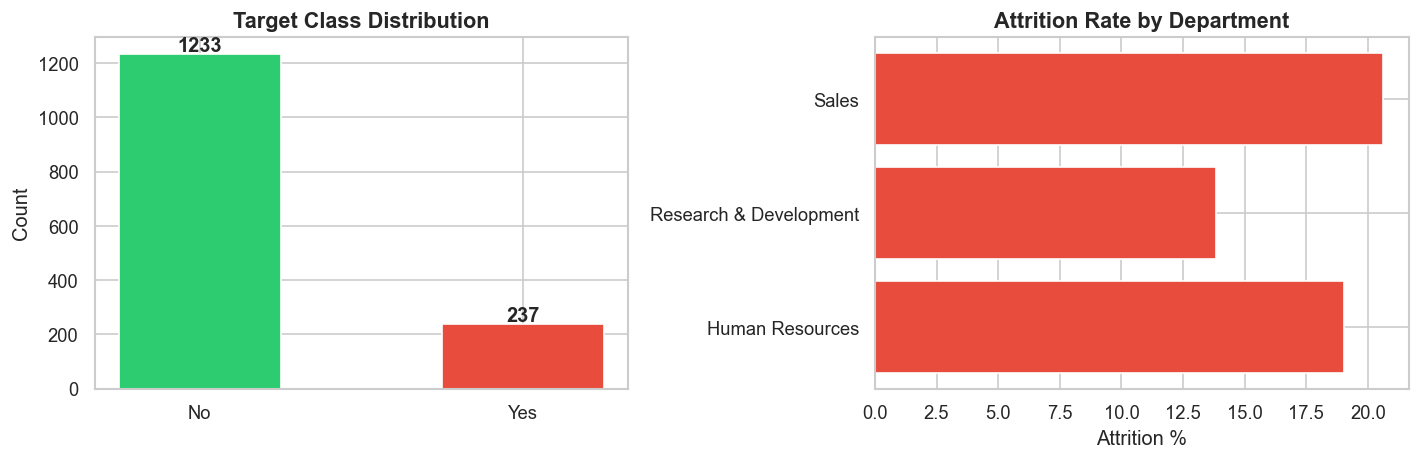

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = df['Attrition'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71','#e74c3c'], width=0.5, edgecolor='white')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')

# Attrition by Department
dept_attr = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100).reset_index()
dept_attr.columns = ['Department','Attrition%']
axes[1].barh(dept_attr['Department'], dept_attr['Attrition%'], color='#e74c3c', edgecolor='white')
axes[1].set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attrition %')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight')
plt.show()

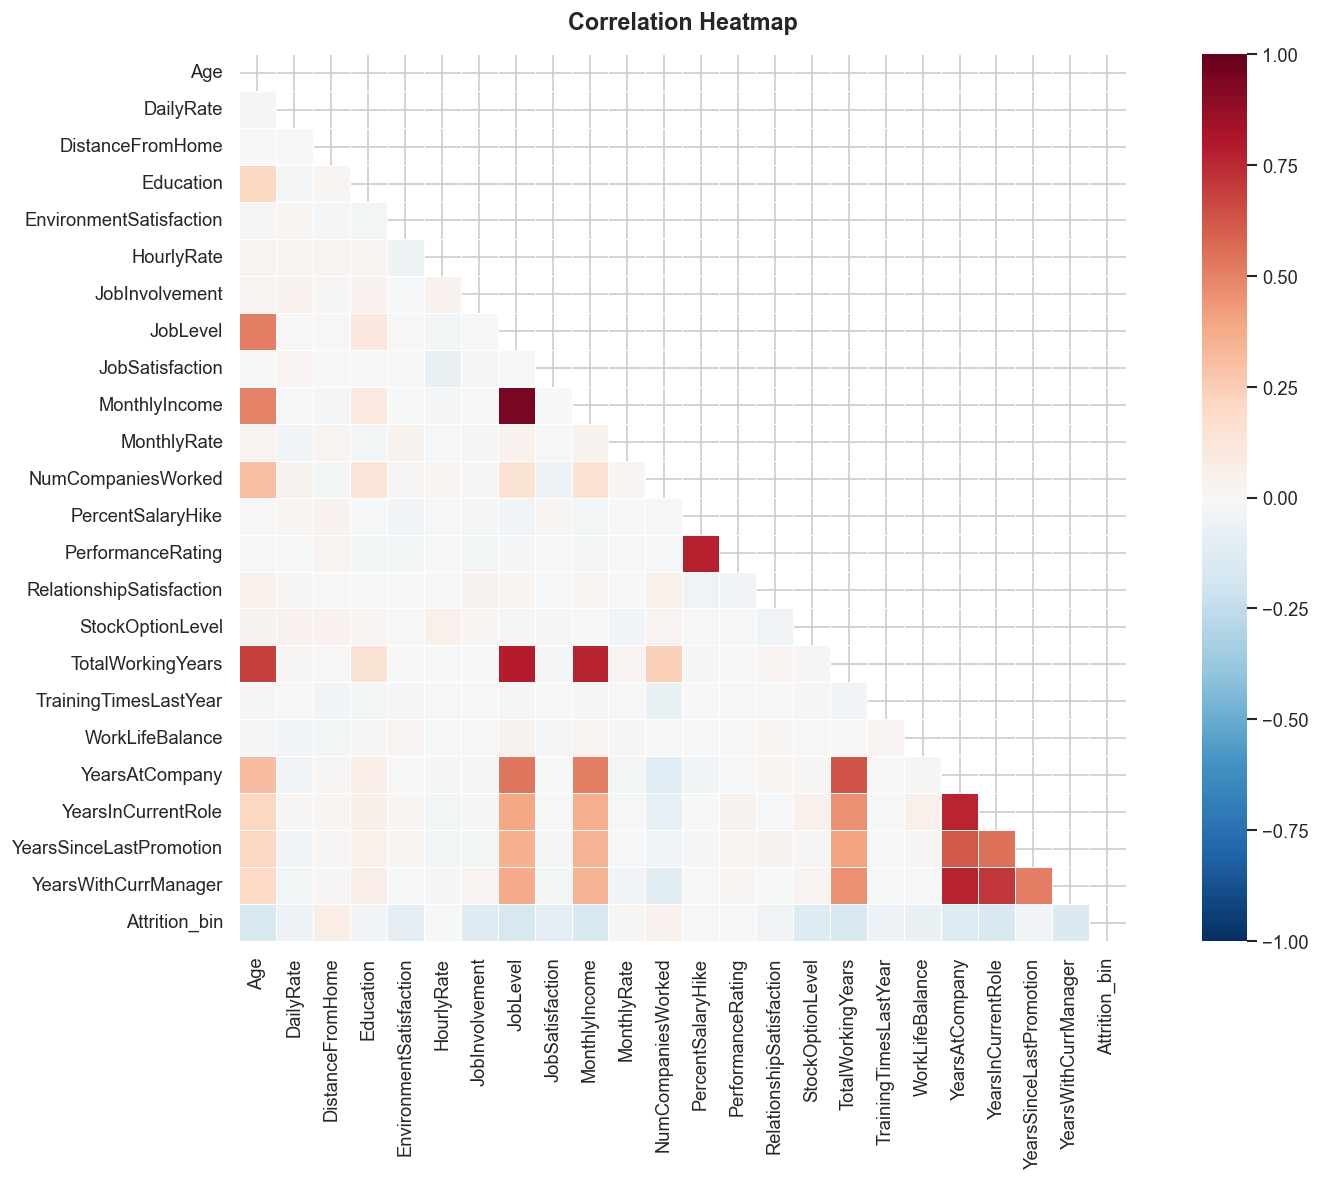

In [6]:
df_num = df.copy()
df_num['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)
num_cols = df_num.select_dtypes(include=np.number).columns.tolist()

corr = df_num[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.4, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

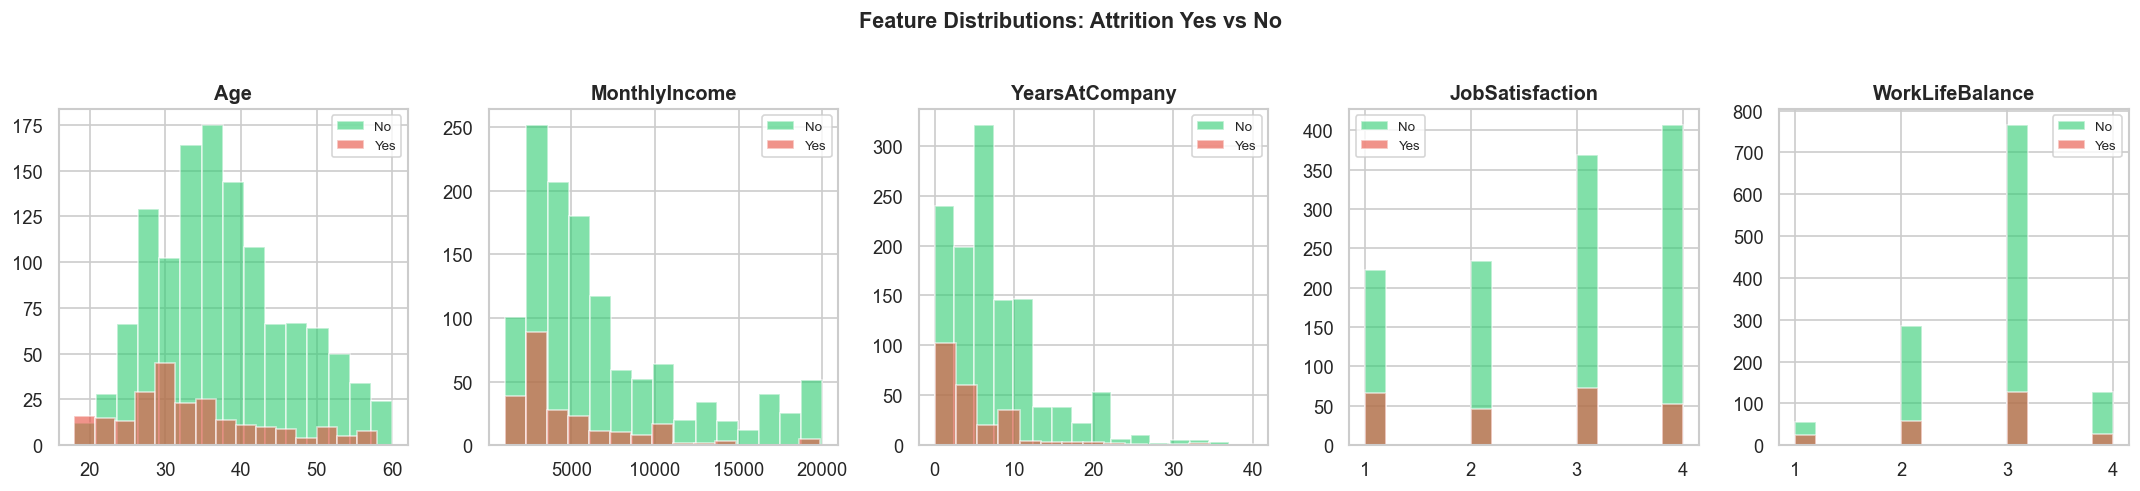

In [7]:
key_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, feat in enumerate(key_features):
    for label, color in [('No','#2ecc71'), ('Yes','#e74c3c')]:
        axes[i].hist(df[df['Attrition']==label][feat], bins=15, alpha=0.6,
                     color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Attrition Yes vs No', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', bbox_inches='tight')
plt.show()

In [8]:
df_eng = df.copy()

# 1. Tenure-to-Salary Ratio — high tenure + low pay = flight risk
df_eng['TenureToSalaryRatio'] = df_eng['YearsAtCompany'] / (df_eng['MonthlyIncome'] / 1000 + 1e-9)

# 2. No Promotion in 3+ years flag
df_eng['NoPromotionFlag'] = (df_eng['YearsSinceLastPromotion'] >= 3).astype(int)

# 3. Overtime risk weight
df_eng['OvertimeRiskWeight'] = (df_eng['OverTime'] == 'Yes').astype(int) * 2

# 4. Composite satisfaction score
df_eng['SatisfactionScore'] = (
    df_eng['JobSatisfaction'] +
    df_eng['EnvironmentSatisfaction'] +
    df_eng['RelationshipSatisfaction']
) / 3

# 5. Career stagnation index
df_eng['CareerStagnation'] = (
    df_eng['YearsInCurrentRole'] / (df_eng['TotalWorkingYears'] + 1)
)

# 6. Low income flag (bottom 25%)
df_eng['LowIncomeFlag'] = (df_eng['MonthlyIncome'] < df_eng['MonthlyIncome'].quantile(0.25)).astype(int)

# 7. New manager risk
df_eng['ManagerRisk'] = (df_eng['YearsWithCurrManager'] < 2).astype(int)

print('✅ Feature engineering complete')
new_feats = ['TenureToSalaryRatio','NoPromotionFlag','OvertimeRiskWeight',
             'SatisfactionScore','CareerStagnation','LowIncomeFlag','ManagerRisk']
print(df_eng[new_feats].describe().round(3).T[['mean','std','min','max']])

✅ Feature engineering complete
                      mean    std  min    max
TenureToSalaryRatio  1.254  0.982  0.0  9.376
NoPromotionFlag      0.254  0.435  0.0  1.000
OvertimeRiskWeight   0.566  0.901  0.0  2.000
SatisfactionScore    2.721  0.628  1.0  4.000
CareerStagnation     0.361  0.254  0.0  0.882
LowIncomeFlag        0.250  0.433  0.0  1.000
ManagerRisk          0.231  0.421  0.0  1.000


In [9]:
df_model = df_eng.copy()
df_model['Attrition'] = (df_model['Attrition'] == 'Yes').astype(int)

# Label encode all categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'Encoding: {cat_cols}')

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

joblib.dump(le_dict, 'label_encoders.pkl')

X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Attrition rate — Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')

Encoding: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Train: (1176, 37) | Test: (294, 37)
Attrition rate — Train: 16.2% | Test: 16.0%


In [10]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)
print(f'After SMOTE: {X_train_res.shape}')
print(f'Class counts: {pd.Series(y_train_res).value_counts().to_dict()}')

After SMOTE: (1972, 37)
Class counts: {0: 986, 1: 986}


In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline
base_lr = LogisticRegression(max_iter=1000, random_state=42)
cv_base = cross_val_score(base_lr, X_train_res, y_train_res, cv=skf, scoring='roc_auc')
print(f'Baseline LR  AUC: {cv_base.mean():.4f} ± {cv_base.std():.4f}')

# Ridge
ridge_lr = LogisticRegression(C=0.1, penalty='l2', max_iter=1000, random_state=42)
cv_ridge = cross_val_score(ridge_lr, X_train_res, y_train_res, cv=skf, scoring='roc_auc')
print(f'Ridge LR     AUC: {cv_ridge.mean():.4f} ± {cv_ridge.std():.4f}')

best_model = ridge_lr if cv_ridge.mean() > cv_base.mean() else base_lr
print(f'\n✅ Best model: {type(best_model).__name__}')

Baseline LR  AUC: 0.8641 ± 0.0094
Ridge LR     AUC: 0.8653 ± 0.0109

✅ Best model: LogisticRegression


In [12]:
# Calibrate
calibrated_model = CalibratedClassifierCV(best_model, cv=5, method='isotonic')
calibrated_model.fit(X_train_res, y_train_res)

y_prob = calibrated_model.predict_proba(X_test_sc)[:, 1]

# Business cost matrix: FN = 5x more costly than FP
COST_FN, COST_FP = 5, 1

thresholds = np.arange(0.1, 0.9, 0.01)
costs = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    costs.append(fn * COST_FN + fp * COST_FP)

optimal_threshold = thresholds[np.argmin(costs)]
y_pred_opt = (y_prob >= optimal_threshold).astype(int)

print(f'✅ Optimal threshold: {optimal_threshold:.2f}')
print(f'\n{classification_report(y_test, y_pred_opt, target_names=["Stay","Leave"])}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

joblib.dump(optimal_threshold, 'optimal_threshold.pkl')

✅ Optimal threshold: 0.51

              precision    recall  f1-score   support

        Stay       0.94      0.82      0.88       247
       Leave       0.44      0.74      0.56        47

    accuracy                           0.81       294
   macro avg       0.69      0.78      0.72       294
weighted avg       0.86      0.81      0.83       294

ROC-AUC: 0.8237


['optimal_threshold.pkl']

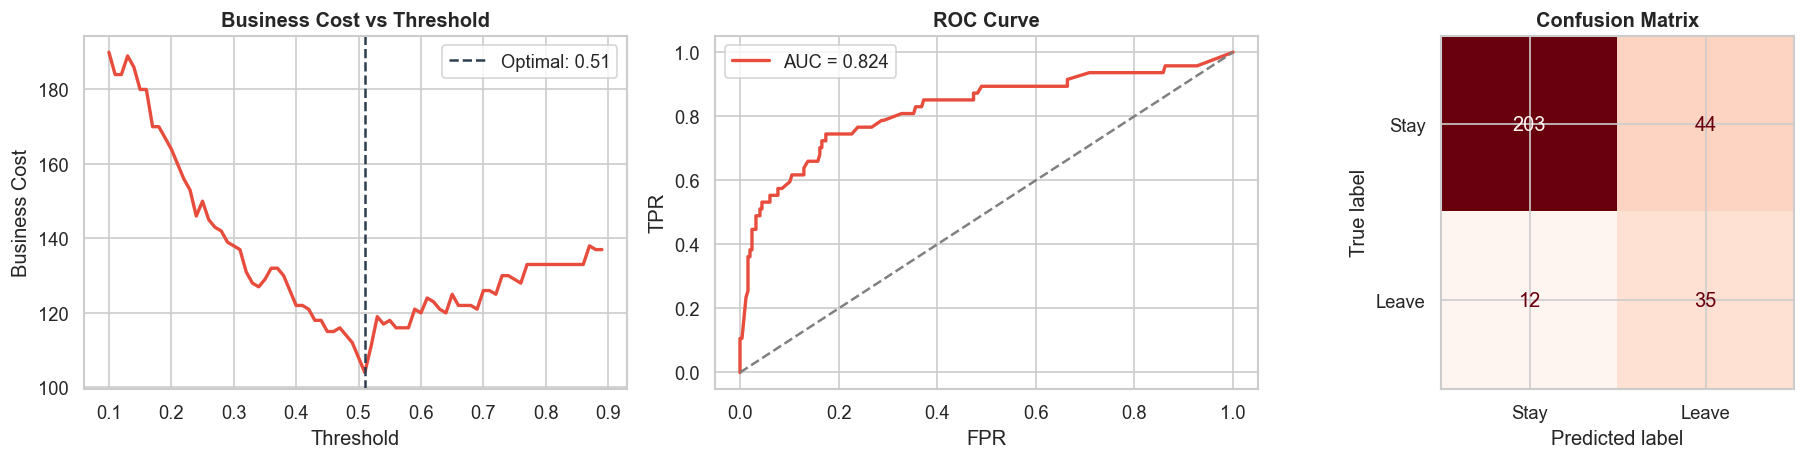

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Cost curve
axes[0].plot(thresholds, costs, color='#e74c3c', linewidth=2)
axes[0].axvline(optimal_threshold, color='#2c3e50', linestyle='--',
                label=f'Optimal: {optimal_threshold:.2f}')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Business Cost')
axes[0].set_title('Business Cost vs Threshold', fontweight='bold')
axes[0].legend()

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_opt),
    display_labels=['Stay','Leave']
).plot(ax=axes[2], cmap='Reds', colorbar=False)
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()

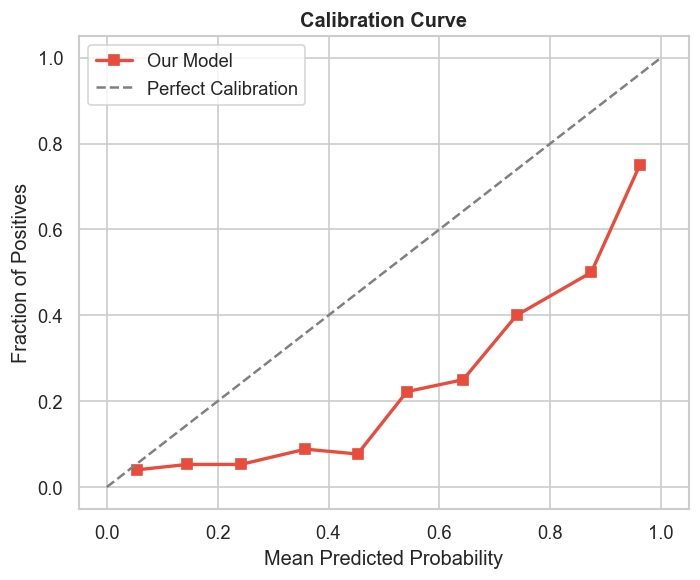

In [14]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, 's-', color='#e74c3c', label='Our Model', linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('calibration_curve.png', bbox_inches='tight')
plt.show()

In [15]:
# Refit plain LR for SHAP (CalibratedClassifierCV wraps estimators)
lr_for_shap = LogisticRegression(C=0.1, penalty='l2', max_iter=1000, random_state=42)
lr_for_shap.fit(X_train_res, y_train_res)

X_test_df = pd.DataFrame(X_test_sc, columns=feature_names)

explainer = shap.LinearExplainer(lr_for_shap, X_train_res, feature_names=feature_names)
shap_values = explainer.shap_values(X_test_sc)

joblib.dump(explainer, 'shap_explainer.pkl')
joblib.dump(lr_for_shap, 'lr_for_shap.pkl')

print(f'✅ SHAP explainer fitted | values shape: {np.array(shap_values).shape}')

✅ SHAP explainer fitted | values shape: (294, 37)


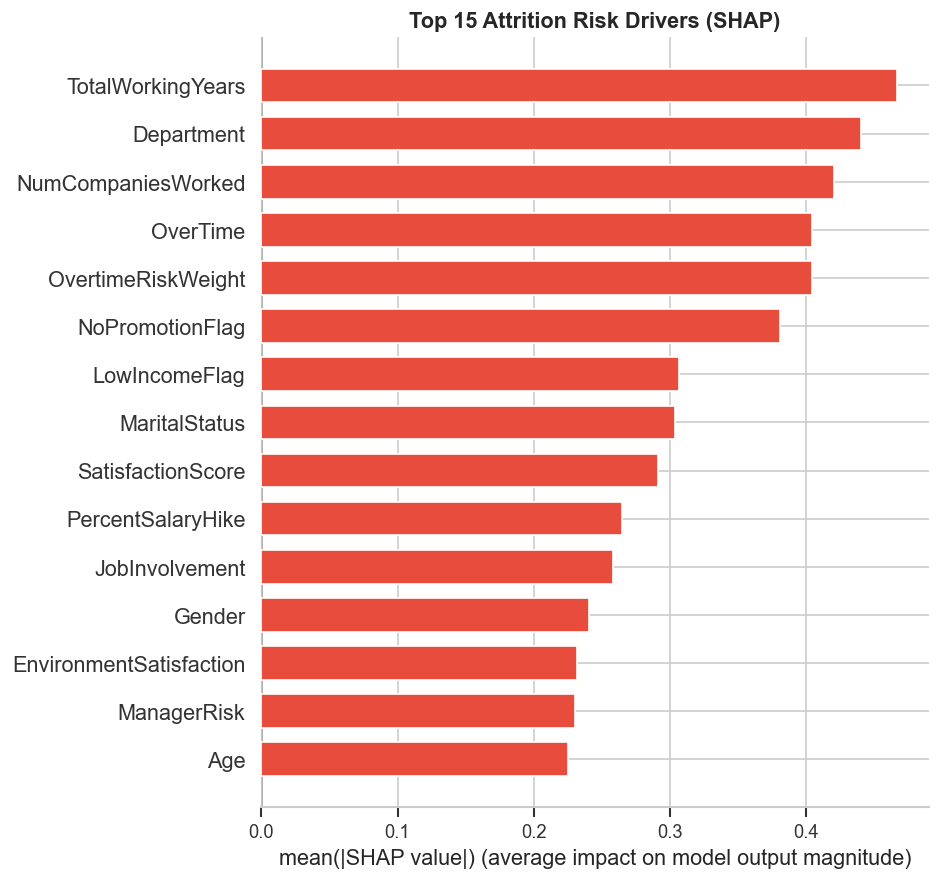

In [16]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, plot_type='bar',
                  max_display=15, show=False, color='#e74c3c')
plt.title('Top 15 Attrition Risk Drivers (SHAP)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_global_importance.png', bbox_inches='tight')
plt.show()

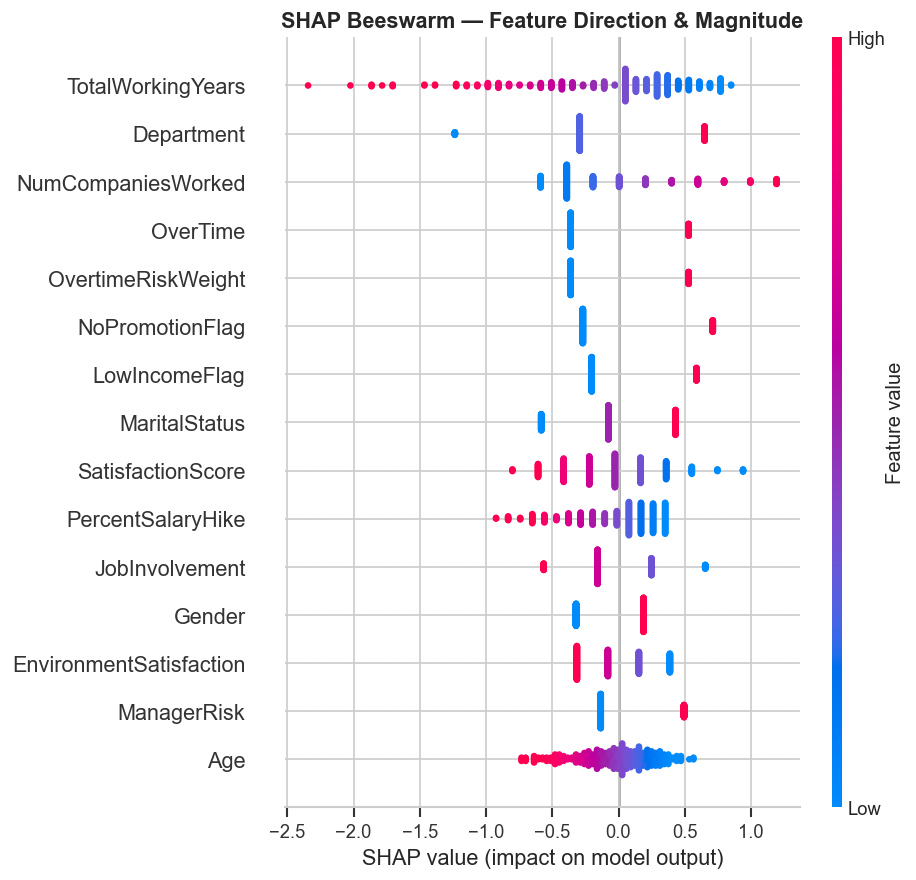

In [17]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Direction & Magnitude', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight')
plt.show()

Highest-risk employee index: 200
Risk probability: 100.0%


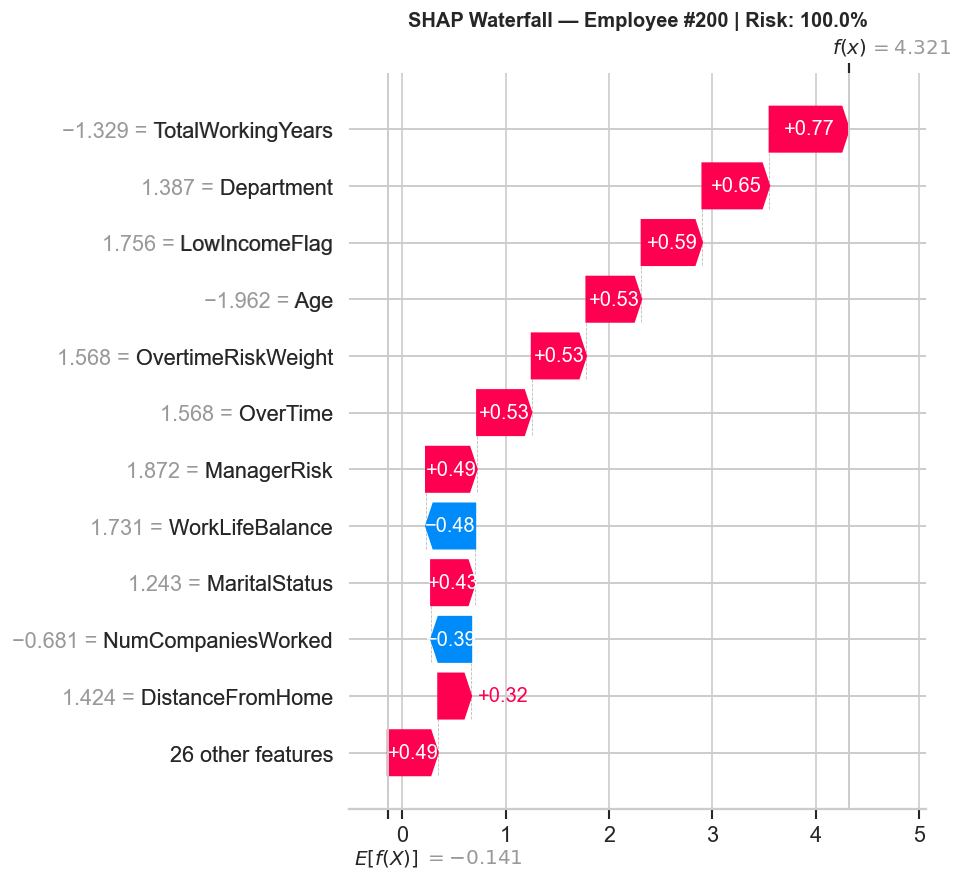

In [18]:
high_risk_idx = np.argmax(y_prob)
print(f'Highest-risk employee index: {high_risk_idx}')
print(f'Risk probability: {y_prob[high_risk_idx]:.1%}')

shap_exp = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[high_risk_idx],
    feature_names=feature_names
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Employee #{high_risk_idx} | Risk: {y_prob[high_risk_idx]:.1%}',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_example.png', bbox_inches='tight')
plt.show()

Mean Expected Cost:   $11,973,737
Median Cost:          $11,939,382
95th Percentile:      $13,226,962
5th Percentile:       $10,768,854


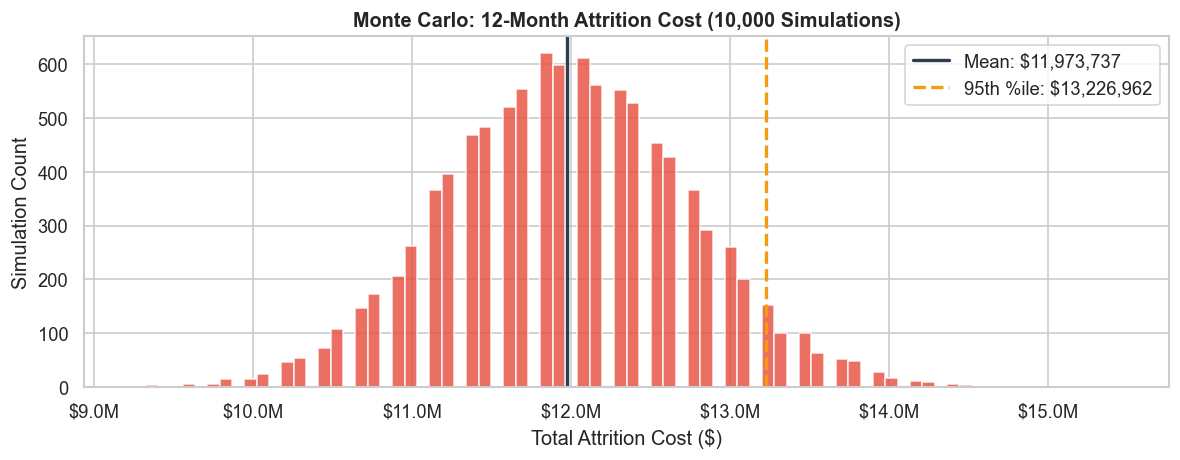

In [19]:
np.random.seed(42)
N_SIMULATIONS = 10_000
avg_monthly_salary = df['MonthlyIncome'].mean()
replacement_cost_per_person = avg_monthly_salary * 12 * 1.5

total_costs = []
for _ in range(N_SIMULATIONS):
    actual_leavers = np.random.binomial(1, y_prob).sum()
    total_costs.append(actual_leavers * replacement_cost_per_person)

total_costs = np.array(total_costs)

print(f'Mean Expected Cost:   ${np.mean(total_costs):,.0f}')
print(f'Median Cost:          ${np.median(total_costs):,.0f}')
print(f'95th Percentile:      ${np.percentile(total_costs, 95):,.0f}')
print(f'5th Percentile:       ${np.percentile(total_costs, 5):,.0f}')

plt.figure(figsize=(10, 4))
plt.hist(total_costs, bins=80, color='#e74c3c', edgecolor='white', alpha=0.8)
plt.axvline(np.mean(total_costs), color='#2c3e50', linewidth=2,
            label=f'Mean: ${np.mean(total_costs):,.0f}')
plt.axvline(np.percentile(total_costs, 95), color='#f39c12', linewidth=2, linestyle='--',
            label=f'95th %ile: ${np.percentile(total_costs,95):,.0f}')
plt.xlabel('Total Attrition Cost ($)')
plt.ylabel('Simulation Count')
plt.title('Monte Carlo: 12-Month Attrition Cost (10,000 Simulations)', fontweight='bold')
plt.legend()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('monte_carlo_cost.png', bbox_inches='tight')
plt.show()

              Avg Risk  Count    Std
JobLevelBand                        
Level 1          0.454    123  0.290
Level 2          0.342     98  0.258
Level 3          0.266     39  0.238
Level 4-5        0.073     34  0.086


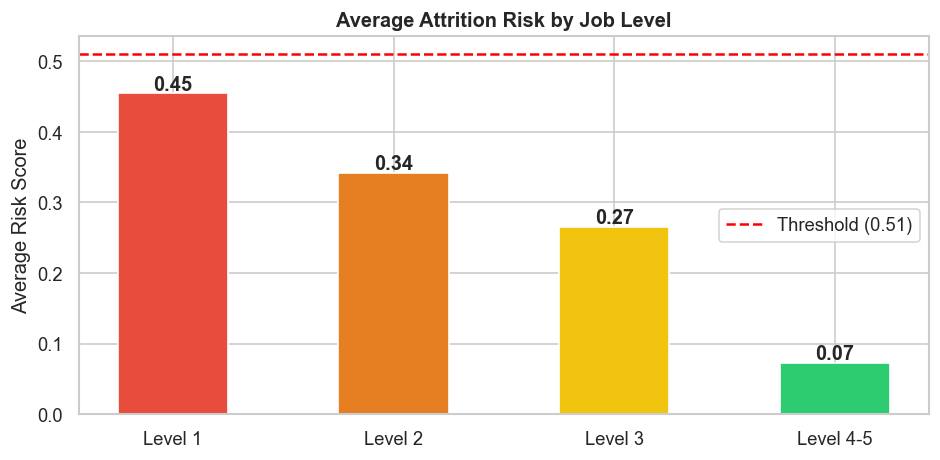

In [20]:
df_test_results = X_test.copy()
df_test_results['RiskScore'] = y_prob
df_test_results['Actual'] = y_test.values
df_test_results['RiskFlag'] = (y_prob >= optimal_threshold).astype(int)
df_test_results['JobLevelBand'] = pd.cut(
    df_test_results['JobLevel'],
    bins=[0,1,2,3,5],
    labels=['Level 1','Level 2','Level 3','Level 4-5']
)

cohort_stats = df_test_results.groupby('JobLevelBand', observed=True)['RiskScore'].agg(['mean','count','std'])
cohort_stats.columns = ['Avg Risk','Count','Std']
print(cohort_stats.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cohort_stats.index.astype(str), cohort_stats['Avg Risk'],
               color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'], edgecolor='white', width=0.5)
ax.set_ylabel('Average Risk Score')
ax.set_title('Average Attrition Risk by Job Level', fontweight='bold')
ax.axhline(optimal_threshold, color='red', linestyle='--', label=f'Threshold ({optimal_threshold:.2f})')
ax.legend()
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('cohort_analysis.png', bbox_inches='tight')
plt.show()

In [21]:
# Save model artifacts
joblib.dump(calibrated_model, 'attrition_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')
joblib.dump(feature_names, 'feature_names.pkl')
joblib.dump(optimal_threshold, 'optimal_threshold.pkl')
joblib.dump(explainer, 'shap_explainer.pkl')
joblib.dump(lr_for_shap, 'lr_for_shap.pkl')

# Score all employees and export for Power BI
X_all_sc = scaler.transform(X)
df_all_risk = X.copy()
df_all_risk['RiskScore']       = calibrated_model.predict_proba(X_all_sc)[:, 1]
df_all_risk['Attrition_Actual'] = y.values
df_all_risk['HighRiskFlag']    = (df_all_risk['RiskScore'] >= optimal_threshold).astype(int)

# Decode categoricals for readability
for col, encoder in le_dict.items():
    if col in df_all_risk.columns:
        df_all_risk[col] = encoder.inverse_transform(df_all_risk[col].astype(int))

df_all_risk['MonthlyIncome']      = df['MonthlyIncome'].values
df_all_risk['ReplacementCostUSD'] = df_all_risk['MonthlyIncome'] * 12 * 1.5

df_all_risk.to_csv('attrition_risk_scored.csv', index=False)
df_all_risk.to_excel('attrition_risk_scored.xlsx', index=False)

# Summary
high_risk_count = df_all_risk['HighRiskFlag'].sum()
est_cost = df_all_risk[df_all_risk['HighRiskFlag']==1]['ReplacementCostUSD'].sum()

print('=' * 55)
print('  FINAL SUMMARY')
print('=' * 55)
print(f'  Total Employees:      {len(df_all_risk):,}')
print(f'  ROC-AUC:              {roc_auc_score(y_test, y_prob):.4f}')
print(f'  Optimal Threshold:    {optimal_threshold:.2f}')
print(f'  High-Risk Employees:  {high_risk_count:,} ({high_risk_count/len(df_all_risk):.1%})')
print(f'  Est. At-Risk Cost:    ${est_cost:,.0f}')
print('=' * 55)
print('  ✅ Run: streamlit run app.py')

  FINAL SUMMARY
  Total Employees:      1,470
  ROC-AUC:              0.8237
  Optimal Threshold:    0.51
  High-Risk Employees:  382 (26.0%)
  Est. At-Risk Cost:    $30,354,228
  ✅ Run: streamlit run app.py
